# Connectivity motifs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
import matplotlib

from brokenaxes import brokenaxes

In [2]:
##  PLOS

plt.rcParams.update({
    # Fonts - Times, 8-12 pt
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 12,                  # Base size 8-12 pt

    # Axes
    "axes.titlesize": 12,             # Axis title size
    "axes.labelsize": 12,             # Axis label size
    "axes.labelweight": "normal",     # Normal weight
    "axes.titleweight": "normal",     # Normal weight for titles

    # Ticks
    "xtick.labelsize": 9,             # X tick label size (8-12)
    "ytick.labelsize": 9,             # Y tick label size (8-12)
    "xtick.direction": "in",          # Tick direction
    "ytick.direction": "in",          # Tick direction

    # Legends
    "legend.fontsize": 12,            # Legend text size (8-12)
    "legend.title_fontsize": 12,      # Legend title size (8-12)
    "legend.loc": 'best',             # Automatic location

    # Resolution
    "figure.dpi": 500,                # Display DPI
    "savefig.dpi": 500,               # Save DPI (300-600)
    "savefig.bbox": "tight",          # Crop whitespace

    # Without LaTeX
    "text.usetex": False,             # PLOS does not accept LaTeX EPS
    "mathtext.fontset": "dejavuserif",# Match math fonts to serif

    # Figsize ?
    "figure.figsize": (16, 6)       # Figsize
    # "figure.figsize": (8, 6)       # Figsize
})

In [23]:
plt.rcParams.update({
    # Fonts - Times, 8-12 pt
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 14,                  # Base size 8-12 pt
    # Axes
    "axes.titlesize": 18,             # Axis title size
    "axes.labelsize": 18,             # Axis label size
    "axes.labelweight": "normal",     # Normal weight
    "axes.titleweight": "normal",     # Normal weight for titles
    # Ticks
    "xtick.labelsize": 18,             # X tick label size (8-12)
    "ytick.labelsize": 18,             # Y tick label size (8-12)
    "xtick.direction": "in",          # Tick direction
    "ytick.direction": "in",          # Tick direction
    # Legends
    "legend.fontsize": 18,            # Legend text size (8-12)
    "legend.title_fontsize": 12,      # Legend title size (8-12)
    "legend.loc": 'best',             # Automatic location
    # Resolution
    # "figure.dpi": 500,                # Display DPI  UNCOMMENT LATER. I commented it out now while I work on it, because Jupyter displayed pixel size = figsize * figure.dpi, causing huge images now in the notebook
    "figure.dpi": 100,
    "savefig.dpi": 500,               # Save DPI (300-600)
    "savefig.bbox": "tight",          # Crop whitespace
    # Without LaTeX
    "text.usetex": False,             # PLOS does not accept LaTeX EPS
    "mathtext.fontset": "dejavuserif",# Match math fonts to serif
    # Make text editable in Inkscape
    "svg.fonttype": 'none',
})

In [3]:
## Reusable color utility
# I use this one
import numpy as np
import matplotlib.pyplot as plt

def make_color_map(values, cmap, vmin=0.25, vmax=1.0):
    '''
    Function that takes array of values and make a colormap for them
    '''
    values_sorted = sorted(values)
    colors = cmap(np.linspace(vmin, vmax, len(values)))
    return dict(zip(values_sorted, colors))

# To be given value
v_rest = [-22, -17, -12.3, -8.5]
pqif_vector = [0, 0.25, 0.5, 0.75, 1]

# Make colors once
color_map_vrest = make_color_map(v_rest, plt.cm.Reds)  # Reds for vrest
color_map_pqif = make_color_map(pqif_vector[1:-1], plt.cm.Greens)  # Greens for pqif

# Explicit endpoints for pqif
color_map_pqif[pqif_vector[0]] = 'black'
color_map_pqif[pqif_vector[-1]] = 'steelblue'


# Path

In [4]:
import os

figure_folder = 'figures'

# Dataframe

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

dynamics = ["oscillations", "sequences"]
# simulations_osc = [1, 2, 3, 4]
# simulations_seq = [9, 10, 11, 12]
# v_rest = [-22, -17, -12.3, -8.5]
slope_qif = 10.74

pqif_values = [0, 0.25, 0.5, 0.75, 1]
lif_mix = [0, 0.25, 0.5, 0.75]
qif = [1]
names = ['LIF', '0.25', '0.5', '0.75', 'QIF']
# # Parámetros estéticos y valores de pqif
# colors = ['firebrick', 'firebrick', 'steelblue']

vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]

motifs = ["tau_rec", "tau_div", "tau_con", "tau_chn"]
motif_labels = {
    "tau_rec": "Reciprocal",
    "tau_div": "Divergent",
    "tau_con": "Convergent",
    "tau_chn": "Chain"
}

dfs = []

for dyn in dynamics:

    if dyn == 'oscillations':
        simulation_number = [i for i in range(1,5)]
    elif dyn == 'sequences':
        simulation_number = [i for i in range(9, 13)]
    else:
        print('Invalid dynamics')
        sys.exit()

    # Crear figura
    # fig, axs = plt.subplots(1, 4, figsize=(16, 6), sharey=True)



    for sim, vr, f in zip(simulation_number, vrest, slope):


        # Cargar datos
        dataframe_title = f'{dyn}/simulation_{sim}/simulation_{sim}_results.csv'
        # dataframe_title = ONEDRIVE_BASE / f"simulation_{sim}_results.csv"
        df_results = pd.read_csv(dataframe_title)  # Has header

        # print(f"{dyn}, sim {sim}:")
        # display(df_results)


        sorted = df_results.sort_values(by=['pqif', 'seed'])

        for pqif in pqif_values:


            df_filtered = df_results[(df_results['pqif'] == pqif) & (df_results['nloop'] == 15)]

            df_temp = df_filtered.copy()

            if pqif == 1:
                vr = None
                f = slope_qif

            df_temp['sim'] = sim
            df_temp['vrest'] = vr
            df_temp['gain'] = f
            


            dfs.append(df_temp)


vertical_stack = pd.concat(dfs, axis=0)
display(vertical_stack)  # All in one dataframe
vertical_stack.to_csv('motif_data.csv', index=False)  # Make csv


# display(test_1)
# display(test_2)

# df_motifs = pd.concat(dfs, ignore_index=True)
# display(df_motifs)

C:\Users\snrambo\AppData\Local\Temp\ipykernel_6288\4177209035.py:81: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  vertical_stack = pd.concat(dfs, axis=0)


,pqif,seed,nloop,sigma2,tau_rec,tau_div,tau_con,tau_chn,sim,vrest,gain
1615,0.0,0,15,13.050491,-0.007263,0.000309,-0.004935,0.000362,1,-8.5,14.44
1631,0.0,1,15,10.858565,0.001052,-0.000127,-0.004942,-0.000161,1,-8.5,14.44
1647,0.0,2,15,10.938580,-0.000472,-0.000404,-0.004941,0.000007,1,-8.5,14.44
1663,0.0,3,15,11.425570,-0.001731,0.000141,-0.004936,0.000019,1,-8.5,14.44
1679,0.0,4,15,10.951790,0.000632,0.000346,-0.004952,0.000036,1,-8.5,14.44
...,...,...,...,...,...,...,...,...,...,...,...
3935,1.0,45,15,9.135735,0.101222,0.021146,-0.004768,-0.003329,12,NaN,10.74
3951,1.0,46,15,8.908171,0.113449,0.018426,-0.004740,-0.003409,12,NaN,10.74
3967,1.0,47,15,9.561989,0.087827,0.025013,-0.004782,-0.003430,12,NaN,10.74
3983,1.0,48,15,7.782268,0.105672,0.017310,-0.004741,-0.002527,12,NaN,10.74


In [5]:
motif_csv_path = 'motif_data.csv'

df_motif = pd.read_csv(motif_csv_path)

display(df_motif.head(60))

dfm = df_motif.copy()

,pqif,seed,nloop,sigma2,tau_rec,tau_div,tau_con,tau_chn,sim,vrest,gain
0,0.00,0,15,13.050491,-0.007263,0.000309,-0.004935,0.000362,1,-8.5,14.44
1,0.00,1,15,10.858565,0.001052,-0.000127,-0.004942,-0.000161,1,-8.5,14.44
2,0.00,2,15,10.938580,-0.000472,-0.000404,-0.004941,0.000007,1,-8.5,14.44
3,0.00,3,15,11.425570,-0.001731,0.000141,-0.004936,0.000019,1,-8.5,14.44
4,0.00,4,15,10.951790,0.000632,0.000346,-0.004952,0.000036,1,-8.5,14.44
5,0.00,5,15,10.422797,-0.013167,0.000520,-0.004939,0.000095,1,-8.5,14.44
6,0.00,6,15,11.296881,-0.002197,0.000760,-0.004899,0.000130,1,-8.5,14.44
7,0.00,7,15,11.402943,-0.003424,0.000711,-0.004930,0.000011,1,-8.5,14.44
8,0.00,8,15,10.957678,0.002859,0.000434,-0.004942,-0.000216,1,-8.5,14.44
9,0.00,9,15,10.433483,-0.004975,0.000010,-0.004960,0.000090,1,-8.5,14.44


# Motif figures

## Use csv

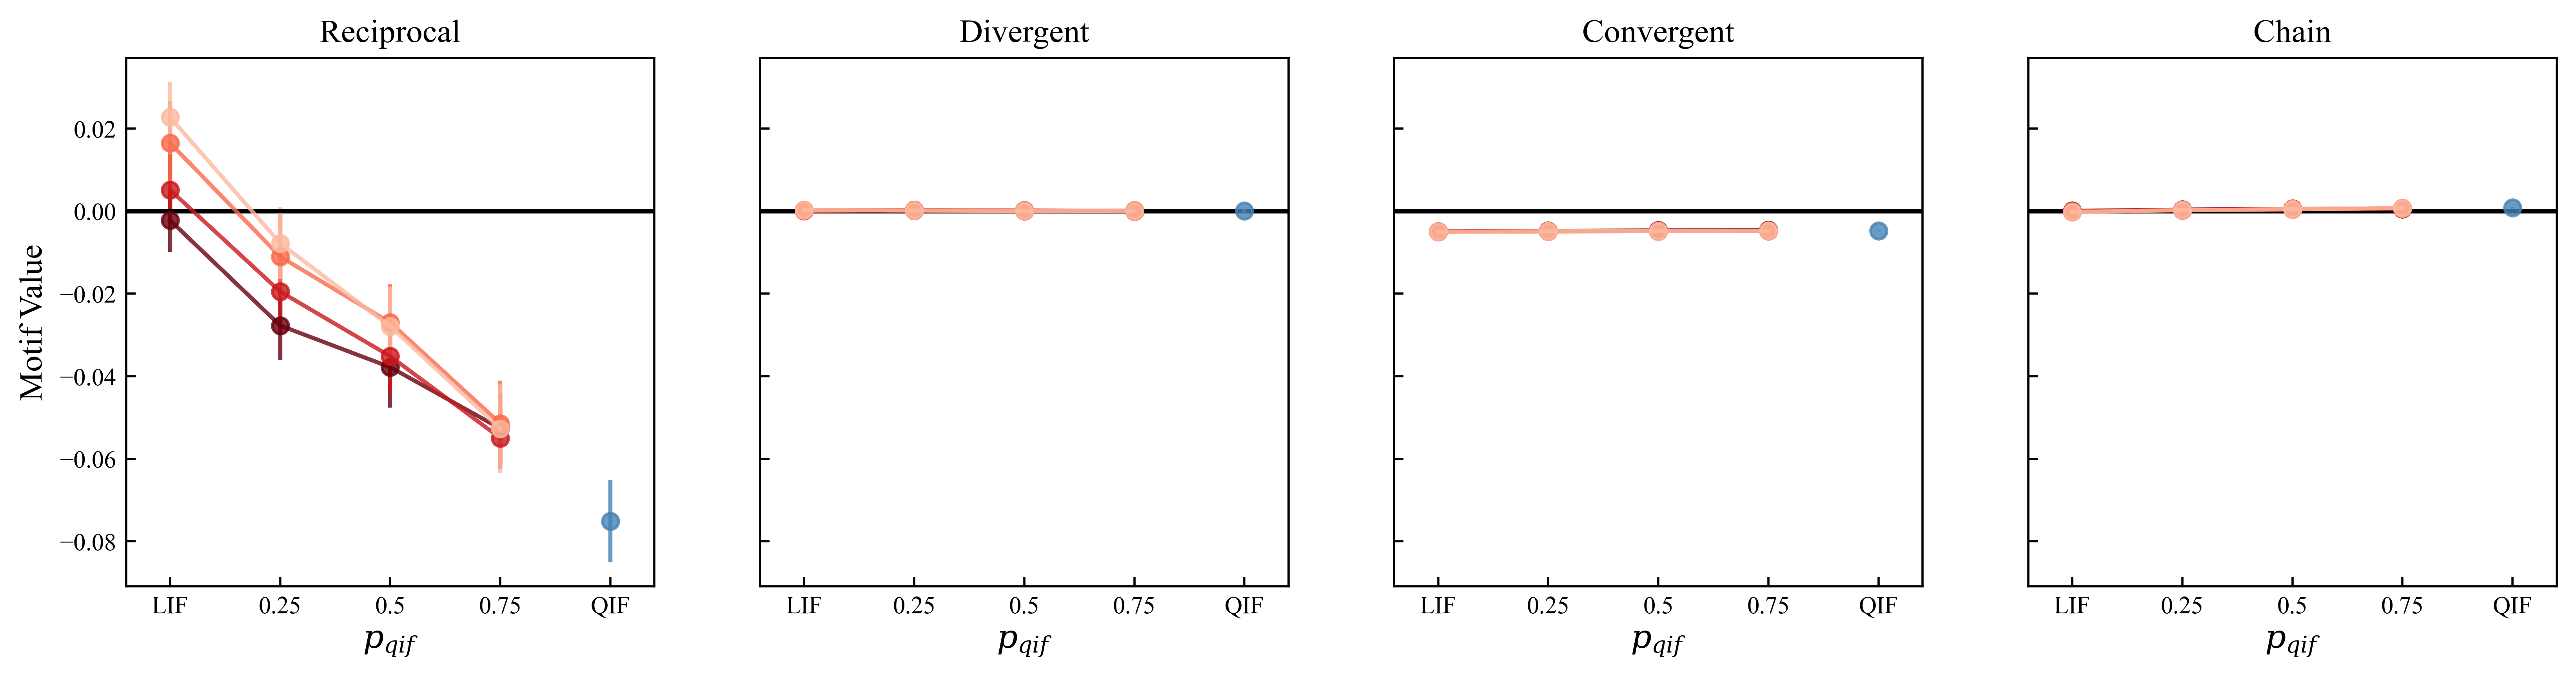

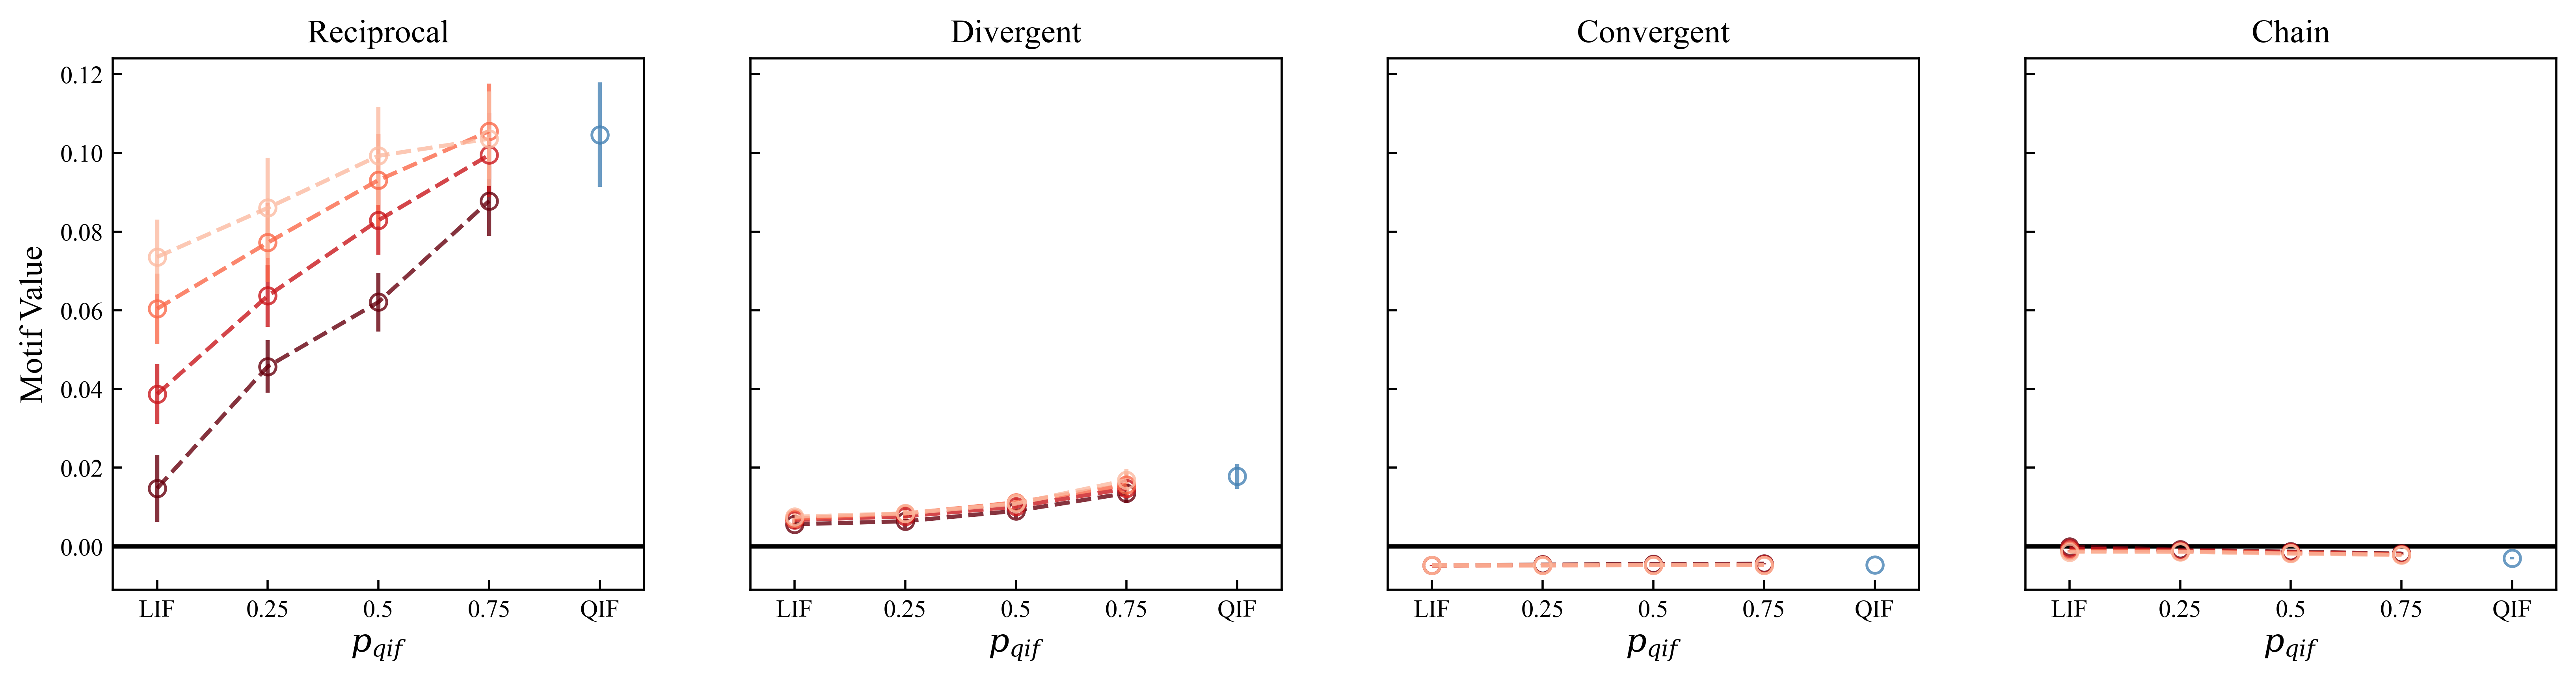

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dynamics = ["oscillations", "sequences"]
slope_qif = 10.74

pqif_values = [0, 0.25, 0.5, 0.75, 1]
lif_mix = [0, 0.25, 0.5, 0.75]
qif = [1]
names = ['LIF', '0.25', '0.5', '0.75', 'QIF']

vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]

motifs = ["tau_rec", "tau_div", "tau_con", "tau_chn"]
motif_labels = {
    "tau_rec": "Reciprocal",
    "tau_div": "Divergent",
    "tau_con": "Convergent",
    "tau_chn": "Chain"
}

for dyn in dynamics:

    if dyn == 'oscillations':
        simulation_number = [i for i in range(1,5)]
        linestyle = '-'
    elif dyn == 'sequences':
        simulation_number = [i for i in range(9, 13)]
        linestyle = '--'
    else:
        print('Invalid dynamics')
        sys.exit()

    # Crear figura
    fig, axs = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
    figname = f"{dyn}_heterogenous_motifs.svg"



    for sim, vr, f in zip(simulation_number, vrest, slope):


        # # Cargar datos
        # dataframe_title = f'{dyn}/simulation_{sim}/simulation_{sim}_results.csv'
        # # dataframe_title = ONEDRIVE_BASE / f"simulation_{sim}_results.csv"
        # df_results = pd.read_csv(dataframe_title)

        df_results = df_motif.copy()

        xs = []
        ys = {motif: [] for motif in motifs}
        yerrs = {motif: [] for motif in motifs}

        # display(df_results)


        # for pqif, name in zip(pqif_values, names):
        for pqif in lif_mix:


            if pqif != 1:
                color = color_map_vrest[vr]
            else:
                color = 'steelblue'

            df_filtered = df_results[(df_results['pqif'] == pqif) & (df_results['sim'] == sim) & (df_results['nloop'] == 15)]  # is now a dataframe for current condition, with 50 seeds

            stats = df_filtered[motifs].agg(["mean", "std"])  # Applies aggregate parameters on columns (motifs) across seeds
            # display(stats)

            xs.append(pqif)

            for i, motif in enumerate(motifs):
                ax = axs[i]  # One ax object per motif
                # e.g. axs[0] -> reciprocal, etc..

                ys[motif].append(stats.loc["mean", motif])
                yerrs[motif].append(stats.loc["std", motif])

        fillstyle = 'full' if dyn == 'oscillations' else 'none'

        for i, motif in enumerate(motifs):
            axs[i].errorbar(
                xs,
                ys[motif],
                yerr=yerrs[motif],
                marker='o',
                fillstyle=fillstyle,
                label=f,
                alpha=0.8,
                linestyle=linestyle,
                color=color_map_vrest[vr]
            )

            axs[i].axhline(0, color='black')
            axs[i].set_xticks(pqif_values, names)
            axs[i].set_xlim(-0.1, 1.1)
            axs[i].set_title(motif_labels[motif])
            axs[i].set_box_aspect(1)
            axs[i].set_xlabel(f"$p_{{qif}}$")
            # axs[i].set_ylim()
            

    # QIF separate
    df_qif = df_results[(df_results['pqif'] == 1)  & (df_results['sim'] == simulation_number[0]) & (df_results['nloop'] == 15)] 

    stats_qif = df_qif[motifs].agg(["mean", "std"])  # Applies aggregate parameters on columns (motifs) across seeds

    ys_qif = {motif: [] for motif in motifs}
    yerrs_qif = {motif: [] for motif in motifs}

    axs[0].set_ylabel(f"Motif Value")


    for i, motif in enumerate(motifs):
        ys_qif[motif].append(stats_qif.loc["mean", motif])
        yerrs_qif[motif].append(stats_qif.loc["std", motif])
        
        axs[i].errorbar(
            1,
            ys_qif[motif],
            yerr=yerrs_qif[motif],
            marker='o',
            fillstyle=fillstyle,
            label="QIF",
            alpha=0.8,
            color='steelblue'
        )

    
    # plt.legend()
    # plt.suptitle(f"{dyn.capitalize()}")
    full_path = os.path.join(figure_folder, figname)
    plt.savefig(full_path, format="svg")
    plt.show

## DF made in loop
Old version

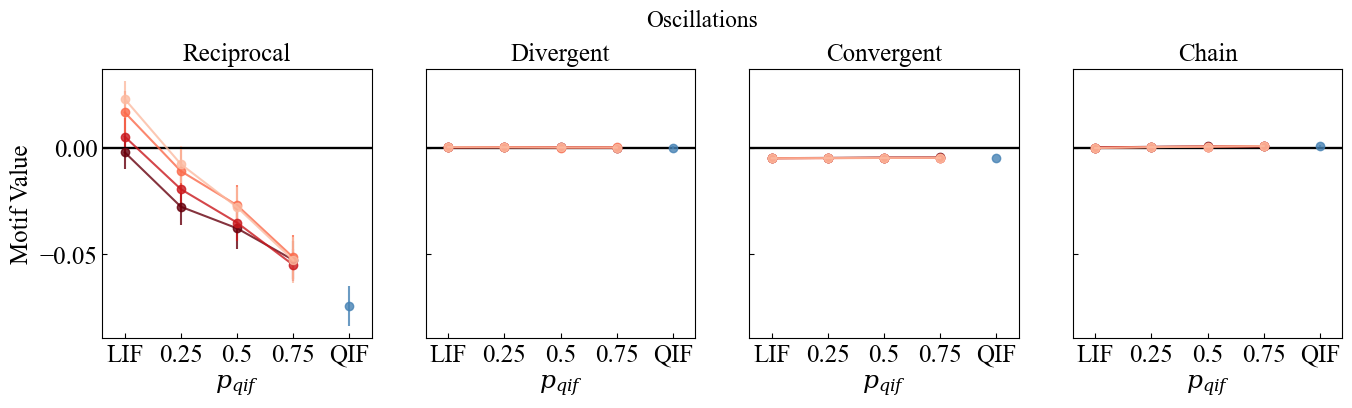

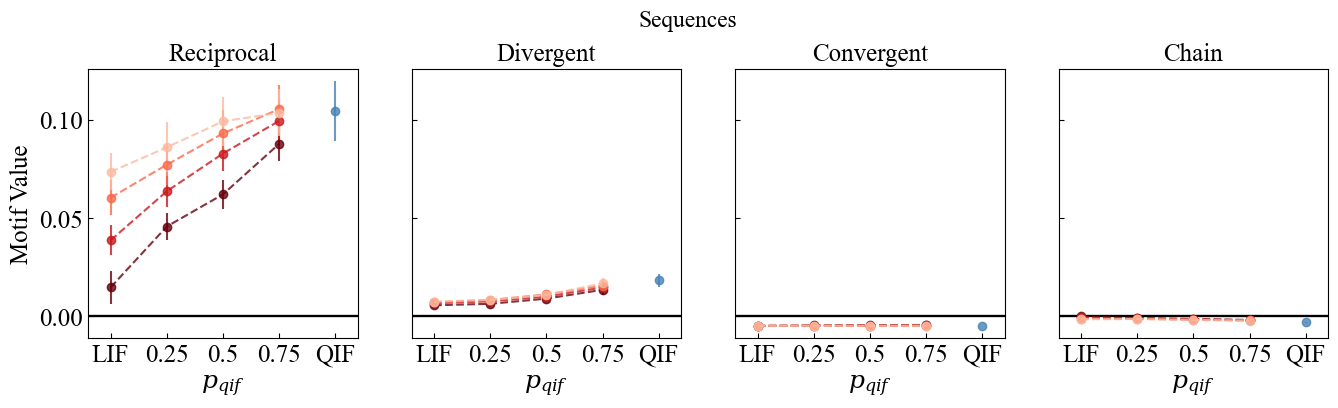

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dynamics = ["oscillations", "sequences"]
# simulations_osc = [1, 2, 3, 4]
# simulations_seq = [9, 10, 11, 12]
# v_rest = [-22, -17, -12.3, -8.5]
slope_qif = 10.74

pqif_values = [0, 0.25, 0.5, 0.75, 1]
lif_mix = [0, 0.25, 0.5, 0.75]
qif = [1]
names = ['LIF', '0.25', '0.5', '0.75', 'QIF']
# # Parámetros estéticos y valores de pqif
# colors = ['firebrick', 'firebrick', 'steelblue']

vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]

motifs = ["tau_rec", "tau_div", "tau_con", "tau_chn"]
motif_labels = {
    "tau_rec": "Reciprocal",
    "tau_div": "Divergent",
    "tau_con": "Convergent",
    "tau_chn": "Chain"
}

for dyn in dynamics:

    if dyn == 'oscillations':
        simulation_number = [i for i in range(1,5)]
        linestyle = '-'
    elif dyn == 'sequences':
        simulation_number = [i for i in range(9, 13)]
        linestyle = '--'
    else:
        print('Invalid dynamics')
        sys.exit()

    # Crear figura
    fig, axs = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
    figname = f"{dyn}_heterogenous_motifs.svg"



    for sim, vr, f in zip(simulation_number, vrest, slope):


        # Cargar datos
        dataframe_title = f'{dyn}/simulation_{sim}/simulation_{sim}_results.csv'
        # dataframe_title = ONEDRIVE_BASE / f"simulation_{sim}_results.csv"
        df_results = pd.read_csv(dataframe_title)

        xs = []
        ys = {motif: [] for motif in motifs}
        yerrs = {motif: [] for motif in motifs}

        # display(df_results)


        # for pqif, name in zip(pqif_values, names):
        for pqif in lif_mix:


            if pqif != 1:
                color = color_map_vrest[vr]
            else:
                color = 'steelblue'

            df_filtered = df_results[(df_results['pqif'] == pqif) & (df_results['nloop'] == 15)]  # is now a dataframe for current condition, with 50 seeds

            stats = df_filtered[motifs].agg(["mean", "std"])  # Applies aggregate parameters on columns (motifs) across seeds
            # display(stats)

            xs.append(pqif)

            for i, motif in enumerate(motifs):
                ax = axs[i]  # One ax object per motif
                # e.g. axs[0] -> reciprocal, etc..

                ys[motif].append(stats.loc["mean", motif])
                yerrs[motif].append(stats.loc["std", motif])

        for i, motif in enumerate(motifs):
            axs[i].errorbar(
                xs,
                ys[motif],
                yerr=yerrs[motif],
                marker='o',
                label=f,
                alpha=0.8,
                linestyle=linestyle,
                color=color_map_vrest[vr]
            )

            axs[i].axhline(0, color='black')
            axs[i].set_xticks(pqif_values, names)
            axs[i].set_xlim(-0.1, 1.1)
            axs[i].set_title(motif_labels[motif])
            axs[i].set_box_aspect(1)
            axs[i].set_xlabel(f"$p_{{qif}}$")
            # axs[i].set_ylim()
            
    # TODO collapse all QIF and plot alone

    # QIF separate
    # TODO decide on a specific simulation?
    df_qif = df_results[(df_results['pqif'] == 1) & (df_results['nloop'] == 15)]  # is now a dataframe for QIF, with 50 seeds TODO

    stats_qif = df_qif[motifs].agg(["mean", "std"])  # Applies aggregate parameters on columns (motifs) across seeds

    # x_qif = [1]  # QIF
    ys_qif = {motif: [] for motif in motifs}
    yerrs_qif = {motif: [] for motif in motifs}

    axs[0].set_ylabel(f"Motif Value")


    for i, motif in enumerate(motifs):
        ys_qif[motif].append(stats_qif.loc["mean", motif])
        yerrs_qif[motif].append(stats_qif.loc["std", motif])
        
        axs[i].errorbar(
            1,
            ys_qif[motif],
            yerr=yerrs_qif[motif],
            marker='o',
            label="QIF",
            alpha=0.8,
            color='steelblue'
        )

    
    # plt.legend()
    plt.suptitle(f"{dyn.capitalize()}")
    full_path = os.path.join(figure_folder, figname)
    plt.savefig(full_path, format="svg")
    plt.show